# Analisis Pola Kriminalitas Chicago 2025
## Association Rule Mining: Apriori vs FP-Growth

---
### Deskripsi Fitur Dataset
| Kolom | Deskripsi |
|---|---|
| `primary_type` | Kategori utama kejahatan (THEFT, BATTERY, dll) |
| `location_description` | Jenis lokasi kejadian (STREET, APARTMENT, dll) |
| `arrest` | Apakah ada penangkapan (True/False) |
| `community_area` | Kode area komunitas di Chicago |
| `date` | Tanggal & waktu kejadian (diekstrak: bulan, hari, jam) |

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
!pip install mlxtend -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, tracemalloc

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

## 1. Load Data

In [3]:
df = pd.read_csv('data kriminal chicago 2025.csv')
print(f'Shape awal: {df.shape}')
print(f'Duplikat  : {df.duplicated().sum()}')
df.head()

Shape awal: (1000, 22)
Duplikat  : 0


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,13815077,JJ228927,2025-04-23 00:00:00,003XX E 84TH ST,0460,BATTERY,SIMPLE,SCHOOL - PUBLIC GROUNDS,False,False,...,6,44,08B,1179729.0,1849371.0,2025,2025-04-30T15:40:44.000,41.741949,-87.617054,"\n, \n(41.741949408, -87.617054222)"
1,13815089,JJ229130,2025-04-23 00:00:00,001XX E SUPERIOR ST,0261,CRIMINAL SEXUAL ASSAULT,AGGRAVATED - HANDGUN,HOTEL / MOTEL,False,False,...,2,8,02,1177508.0,1905401.0,2025,2025-04-30T15:40:44.000,41.895751,-87.623496,"\n, \n(41.895750913, -87.623495923)"
2,13814553,JJ228348,2025-04-23 00:00:00,0000X W CHESTNUT ST,0583,STALKING,CYBERSTALKING,APARTMENT,False,True,...,42,8,08A,1175936.0,1906207.0,2025,2025-04-30T15:40:44.000,41.897998,-87.629245,"\n, \n(41.897998161, -87.629245169)"
3,13820835,JJ236276,2025-04-23 00:00:00,001XX N LECLAIRE AVE,1130,DECEPTIVE PRACTICE,FRAUD OR CONFIDENCE GAME,APARTMENT,False,False,...,28,25,11,NaN,NaN,2025,2025-04-30T15:40:44.000,NaN,NaN,NaN
4,13818089,JJ233007,2025-04-23 00:00:00,087XX S EXCHANGE AVE,0930,MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,STREET,False,False,...,10,46,07,1197281.0,1847639.0,2025,2025-04-30T15:40:44.000,41.736778,-87.552803,"\n, \n(41.736777767, -87.552802808)"


## 2. Preprocessing

*Seleksi Kolom Relevan*

In [4]:
kolom = ['date', 'primary_type', 'location_description',
         'arrest', 'community_area']
df = df[kolom].copy()

*Ekstrak fitur waktu dari date*

In [5]:
df['date'] = pd.to_datetime(df['date'])

*Hapus month (tidak variatif karena semua datasenya bulan April)*

In [6]:
df['date'] = pd.to_datetime(df['date'])
df['week_of_month'] = df['date'].dt.day.apply(
    lambda d: f'Minggu_{(d-1)//7 + 1}'
)
df['week_type'] = df['date'].dt.dayofweek.apply(
    lambda d: 'Weekend' if d >= 5 else 'Weekday'
)
df['hour_bin'] = pd.cut(df['date'].dt.hour,
                        bins=[0,6,12,18,24],
                        labels=['Dini_Hari','Pagi','Siang','Malam'],
                        right=False)
df.drop(columns='date', inplace=True)

*Binning community_area ke zona*

In [7]:
df['community_area'] = pd.cut(df['community_area'].astype(float),
                               bins=[0,20,40,60,80],
                               labels=['Area_Utara','Area_Tengah','Area_Selatan','Area_Lainnya'])

*Encode arrest jadi label*

In [8]:
df['arrest'] = df['arrest'].astype(str).str.upper()\
                           .map({'TRUE': 'ARREST_YES', 'FALSE': 'ARREST_NO'})

*Handling Missing Value*

In [9]:
print('Missing sebelum:', df.isnull().sum().sum())
df = df.apply(lambda x: x.fillna(x.mode()[0]))
print('Missing setelah:', df.isnull().sum().sum())

Missing sebelum: 1
Missing setelah: 0


In [10]:
print(f'\nShape final: {df.shape}')
df.head()


Shape final: (1000, 7)


,primary_type,location_description,arrest,community_area,week_of_month,week_type,hour_bin
0,BATTERY,SCHOOL - PUBLIC GROUNDS,ARREST_NO,Area_Selatan,Minggu_4,Weekday,Dini_Hari
1,CRIMINAL SEXUAL ASSAULT,HOTEL / MOTEL,ARREST_NO,Area_Utara,Minggu_4,Weekday,Dini_Hari
2,STALKING,APARTMENT,ARREST_NO,Area_Utara,Minggu_4,Weekday,Dini_Hari
3,DECEPTIVE PRACTICE,APARTMENT,ARREST_NO,Area_Tengah,Minggu_4,Weekday,Dini_Hari
4,MOTOR VEHICLE THEFT,STREET,ARREST_NO,Area_Selatan,Minggu_4,Weekday,Dini_Hari


## 3. EDA — Distribusi Data

*Distribusi tiap fitur*

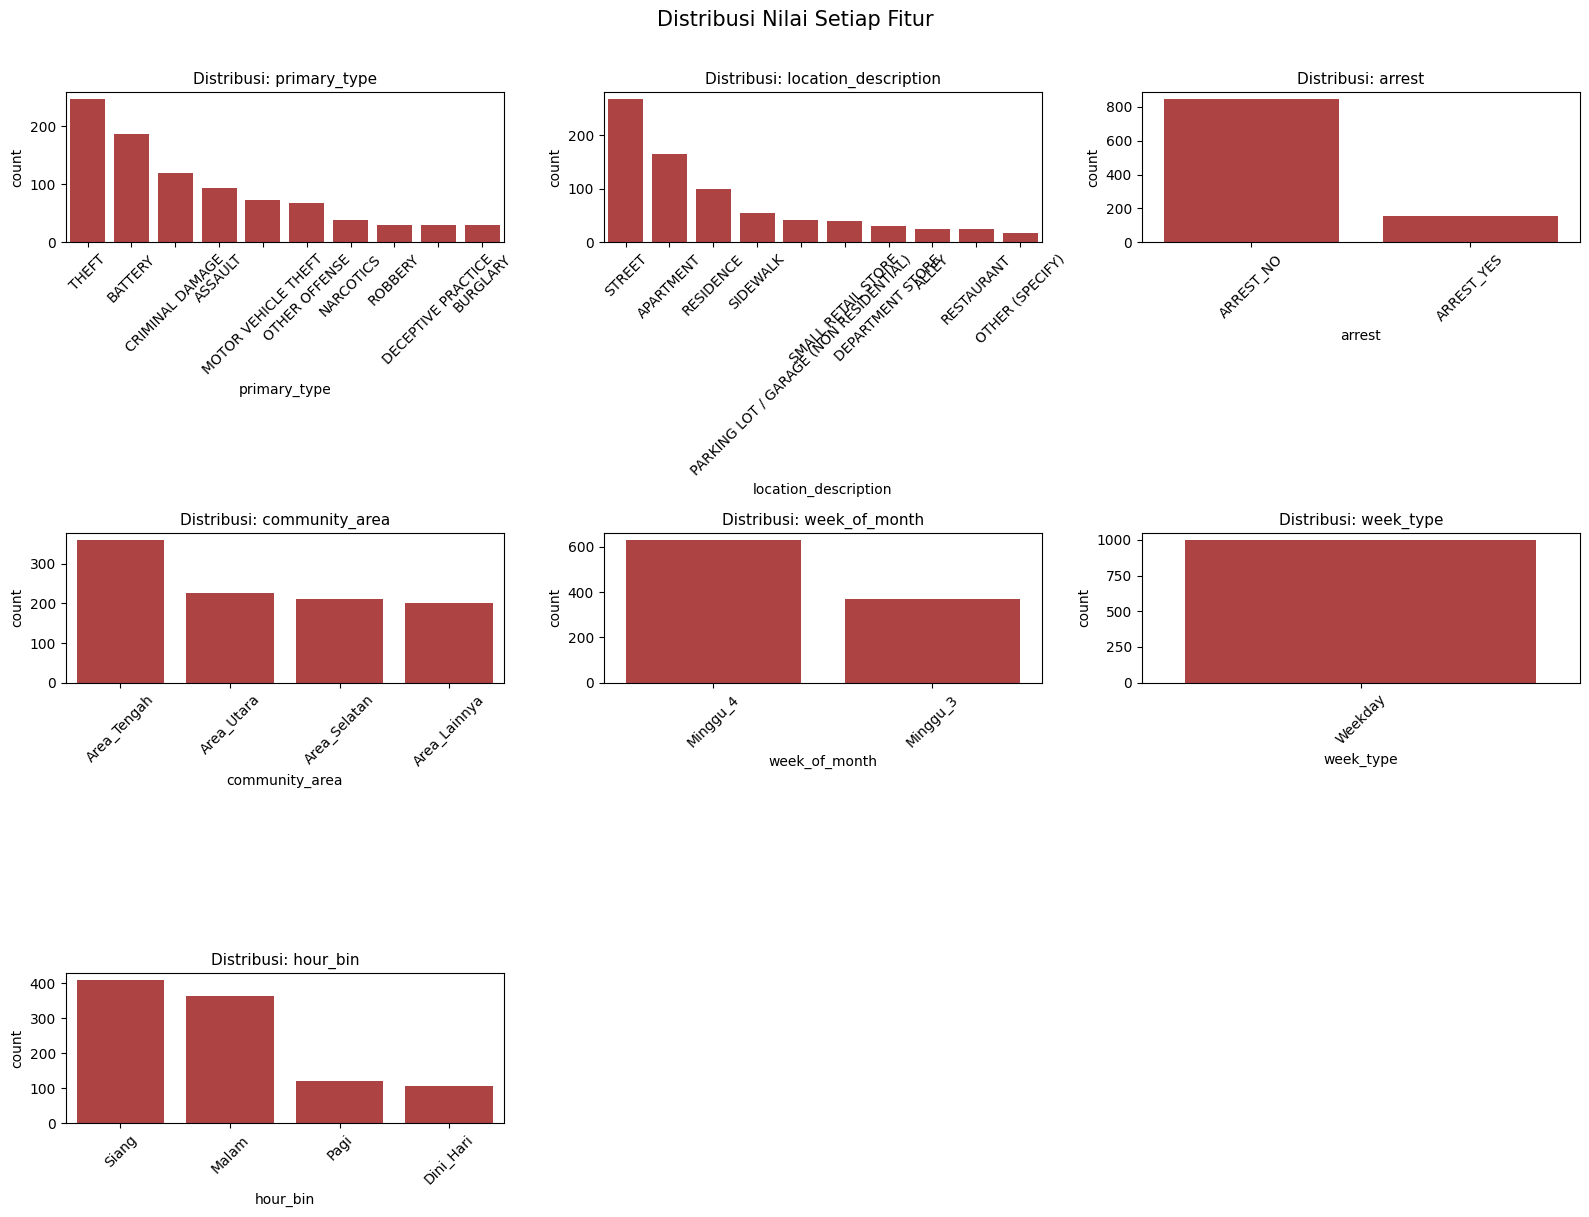

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    order = df[col].astype(str).value_counts().index[:10]
    sns.countplot(data=df, x=col, order=order, color='#bf3231', ax=axes[idx])
    axes[idx].set_title(f'Distribusi: {col}', fontsize=11)
    axes[idx].tick_params(axis='x', rotation=45)

for ax in axes[len(df.columns):]:
    ax.set_visible(False)

plt.suptitle('Distribusi Nilai Setiap Fitur', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Pembentukan Transaksi

In [12]:
transaksi = df.astype(str).values.tolist()

te = TransactionEncoder()
df_enc = pd.DataFrame(te.fit_transform(transaksi), columns=te.columns_)

print(f'Jumlah transaksi : {df_enc.shape[0]}')
print(f'Jumlah item unik : {df_enc.shape[1]}')
df_enc.head(3)

Jumlah transaksi : 1000
Jumlah item unik : 87


,ABANDONED BUILDING,AIRPORT EXTERIOR - NON-SECURE AREA,AIRPORT TERMINAL UPPER LEVEL - SECURE AREA,ALLEY,APARTMENT,APPLIANCE STORE,ARREST_NO,ARREST_YES,ARSON,ASSAULT,...,SMALL RETAIL STORE,STALKING,STREET,Siang,THEFT,VACANT LOT,VACANT LOT / LAND,VEHICLE NON-COMMERCIAL,WEAPONS VIOLATION,Weekday
0,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,True,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True


## 5. Mining — Apriori vs FP-Growth (Benchmarking)

In [13]:
MIN_SUPPORT = 0.03

APRIORI

In [14]:
tracemalloc.start()
t0 = time.time()
fi_apriori = apriori(df_enc, min_support=MIN_SUPPORT, use_colnames=True)
t_apriori  = time.time() - t0
_, mem_apriori = tracemalloc.get_traced_memory()
tracemalloc.stop()

FP-GROWTH

In [15]:
tracemalloc.start()
t0 = time.time()
fi_fp = fpgrowth(df_enc, min_support=MIN_SUPPORT, use_colnames=True)
t_fp  = time.time() - t0
_, mem_fp = tracemalloc.get_traced_memory()
tracemalloc.stop()

*Komputasi*

In [16]:
print('='*45)
print(f'{'Algoritma':<15} {'Runtime':>10} {'Memori (KB)':>14} {'Itemsets':>10}')
print('-'*45)
print(f'{'Apriori':<15} {t_apriori:>9.4f}s {mem_apriori/1024:>13.2f} {len(fi_apriori):>10}')
print(f'{'FP-Growth':<15} {t_fp:>9.4f}s {mem_fp/1024:>13.2f} {len(fi_fp):>10}')
print('='*45)

Algoritma          Runtime    Memori (KB)   Itemsets
---------------------------------------------
Apriori            0.3302s       6103.66        631
FP-Growth         42.5711s       1606.06        631


## 6. Generate Association Rules

In [17]:
MIN_CONFIDENCE = 0.7

In [ ]:
rules_apriori = association_rules(fi_apriori, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules_fp      = association_rules(fi_fp,      metric='confidence', min_threshold=MIN_CONFIDENCE)

*Filter lift > 1 (hanya rules yang bermakna)*

In [19]:
rules_apriori = rules_apriori[rules_apriori['lift'] > 1].sort_values('lift', ascending=False)
rules_fp      = rules_fp[rules_fp['lift'] > 1].sort_values('lift', ascending=False)

In [20]:
print(f'Rules Apriori  : {len(rules_apriori)}')
print(f'Rules FP-Growth: {len(rules_fp)}')

Rules Apriori  : 351
Rules FP-Growth: 351


*Deduplikasi rules redundan*

In [24]:
def deduplikasi_rules(rules):
    seen = set()
    idx_unik = []
    for i, row in rules.iterrows():
        semua_item = frozenset(row['antecedents']) | frozenset(row['consequents'])
        if semua_item not in seen:
            seen.add(semua_item)
            idx_unik.append(i)
    return rules.loc[idx_unik]

rules_fp_clean      = deduplikasi_rules(rules_fp).copy()
rules_apriori_clean = deduplikasi_rules(rules_apriori).copy()

print(f'FP-Growth : {len(rules_fp)} → {len(rules_fp_clean)} setelah deduplikasi')
print(f'Apriori   : {len(rules_apriori)} → {len(rules_apriori_clean)} setelah deduplikasi')

FP-Growth : 351 → 202 setelah deduplikasi
Apriori   : 351 → 202 setelah deduplikasi


*Filter berdasarkan inti rule (abaikan item waktu)*

In [26]:
item_waktu = {'Weekday', 'Weekend', 'Minggu_1', 'Minggu_2', 'Minggu_3', 'Minggu_4',
              'Pagi', 'Siang', 'Malam', 'Dini_Hari'}

In [27]:
rules_fp_clean['core_consequent'] = rules_fp_clean['consequents'].apply(
    lambda x: frozenset(i for i in x if i not in item_waktu)
)
rules_fp_clean['core_antecedent'] = rules_fp_clean['antecedents'].apply(
    lambda x: frozenset(i for i in x if i not in item_waktu)
)
rules_fp_clean['core_key'] = rules_fp_clean.apply(
    lambda r: str(sorted(list(r['core_antecedent']))) + '→' +
              str(sorted(list(r['core_consequent']))), axis=1
)

rules_best = (rules_fp_clean
              .sort_values('lift', ascending=False)
              .drop_duplicates(subset='core_key')
              .reset_index(drop=True))

rules_best = rules_best[rules_best['core_consequent'].apply(len) > 0]

*Ditambahkan rule string*

In [28]:
rules_best['rule_string'] = rules_best.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}",
    axis=1
)

print(f'Rules final: {len(rules_best)}')
rules_best[['rule_string','support','confidence','lift']].head(15)

Rules final: 36


,rule_string,support,confidence,lift
0,"NARCOTICS → Weekday, ARREST_YES",0.034,0.894737,5.698961
1,"MOTOR VEHICLE THEFT, Minggu_4 → Weekday, STREE...",0.030,0.750000,3.472222
2,"SMALL RETAIL STORE → Weekday, THEFT",0.030,0.769231,3.126954
3,"Weekday, MOTOR VEHICLE THEFT, Minggu_4 → STREET",0.031,0.775000,2.902622
4,"ARREST_NO, MOTOR VEHICLE THEFT → STREET",0.049,0.710145,2.659719
5,"Dini_Hari, STREET → ARREST_NO, Weekday, Minggu_4",0.033,0.942857,1.742804
6,"Dini_Hari, Weekday → ARREST_NO, Minggu_4",0.096,0.905660,1.674049
7,"Area_Tengah, Pagi → ARREST_NO, Minggu_4",0.034,0.871795,1.611451
13,"ROBBERY, Weekday → ARREST_NO",0.030,1.000000,1.186240
14,"THEFT, STREET → Weekday, ARREST_NO",0.043,1.000000,1.186240


Hasil Apriori

In [35]:
print("HASIL APRIORI — Top 15 Rules by Lift")
rules_apriori_clean['rule_string'] = rules_apriori_clean.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}",
    axis=1
)
display(rules_apriori_clean[['rule_string','support','confidence','lift']]
        .sort_values('lift', ascending=False)
        .head(15))

HASIL APRIORI — Top 15 Rules by Lift


,rule_string,support,confidence,lift
226,"NARCOTICS → Weekday, ARREST_YES",0.034,0.894737,5.698961
26,NARCOTICS → ARREST_YES,0.034,0.894737,5.698961
540,"MOTOR VEHICLE THEFT, Minggu_4 → ARREST_NO, STREET",0.030,0.750000,3.472222
789,"Weekday, MOTOR VEHICLE THEFT, Minggu_4 → ARRES...",0.030,0.750000,3.472222
313,"Weekday, SMALL RETAIL STORE → THEFT",0.030,0.769231,3.126954
52,SMALL RETAIL STORE → THEFT,0.030,0.769231,3.126954
669,"MOTOR VEHICLE THEFT, Minggu_4 → Weekday, STREET",0.031,0.775000,2.902622
287,"MOTOR VEHICLE THEFT, Minggu_4 → STREET",0.031,0.775000,2.902622
39,MOTOR VEHICLE THEFT → STREET,0.053,0.726027,2.719204
291,"MOTOR VEHICLE THEFT → Weekday, STREET",0.053,0.726027,2.719204


## 7. Visualisasi Rules

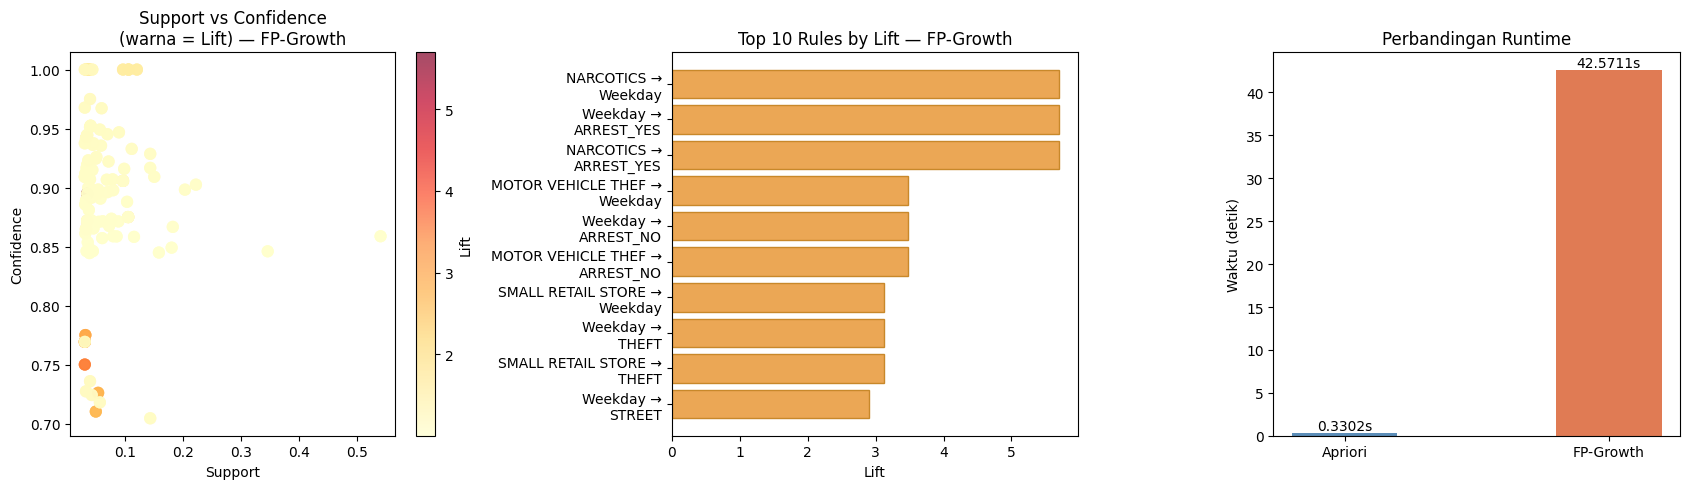

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (1) Scatter support vs confidence — FP-Growth
sc = axes[0].scatter(rules_fp['support'], rules_fp['confidence'],
                     c=rules_fp['lift'], cmap='YlOrRd', alpha=0.7, s=60)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Support vs Confidence\n(warna = Lift) — FP-Growth')

# (2) Top 10 rules by Lift — bar chart
top10 = rules_fp.head(10).copy()
top10['rule'] = [f"{str(list(a)[0])[:18]} →\n{str(list(c)[0])[:18]}"
                 for a, c in zip(top10['antecedents'], top10['consequents'])]
axes[1].barh(top10['rule'], top10['lift'], color='#EBA755', edgecolor='#c8882a')
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 10 Rules by Lift — FP-Growth')
axes[1].invert_yaxis()

# (3) Perbandingan runtime Apriori vs FP-Growth
algos   = ['Apriori', 'FP-Growth']
runtimes = [t_apriori, t_fp]
bars = axes[2].bar(algos, runtimes, color=['#5B8DB8','#E07B54'], width=0.4)
for bar, val in zip(bars, runtimes):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}s', ha='center', va='bottom', fontsize=10)
axes[2].set_ylabel('Waktu (detik)')
axes[2].set_title('Perbandingan Runtime')

plt.tight_layout()
plt.savefig('crime_rules_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Interpretasi Rules

### Ringkasan Hasil Mining
Dari proses FP-Growth ditemukan **36 rules unik** setelah deduplikasi,
dengan minimum support 0.03, confidence 0.7, dan lift > 1.

---

### Kelompok 1 — Narkotika & Penangkapan (Lift tertinggi)
| Rule | Confidence | Lift |
|------|-----------|------|
| NARCOTICS → ARREST_YES, Weekday | 89.5% | 5.70 |

**Interpretasi:** Kasus narkotika hampir pasti berujung penangkapan (89.5%),
terutama di hari kerja. Lift 5.70 menunjukkan hubungan ini 5.7× lebih kuat
dari kebetulan. Hal ini mengindikasikan bahwa operasi penindakan narkotika
dilakukan secara aktif pada hari kerja.

---

### Kelompok 2 — Pencurian Kendaraan & Lokasi (Lift tinggi)
| Rule | Confidence | Lift |
|------|-----------|------|
| Minggu_4, MOTOR VEHICLE THEFT → ARREST_NO, STREET | 75.0% | 3.47 |
| Minggu_4, MOTOR VEHICLE THEFT, Weekday → STREET | 77.5% | 2.90 |
| MOTOR VEHICLE THEFT, ARREST_NO → STREET | 71.0% | 2.66 |
| Minggu_4, MOTOR VEHICLE THEFT → ARREST_NO | 97.5% | 1.16 |

**Interpretasi:** Pencurian kendaraan bermotor sangat dominan terjadi di
jalanan (STREET) pada minggu ke-4 bulan, dan pelaku **jarang tertangkap**
(confidence ARREST_NO hingga 97.5%). Ini menjadi temuan kritis bahwa perlu
peningkatan patroli di jalanan pada akhir bulan.

---

### Kelompok 3 — Pencurian di Toko Ritel
| Rule | Confidence | Lift |
|------|-----------|------|
| SMALL RETAIL STORE → THEFT, Weekday | 76.9% | 3.13 |

**Interpretasi:** Kejahatan di toko ritel kecil hampir selalu berupa
pencurian dan terjadi di hari kerja. Pemilik toko ritel perlu meningkatkan
kewaspadaan dan sistem keamanan terutama pada hari Senin–Jumat.

---

### Kelompok 4 — Kejahatan Dini Hari & Akhir Bulan
| Rule | Confidence | Lift |
|------|-----------|------|
| Dini_Hari, STREET → Minggu_4, ARREST_NO, Weekday | 94.3% | 1.74 |
| Dini_Hari, Weekday → Minggu_4, ARREST_NO | 90.6% | 1.67 |
| Area_Tengah, Pagi → Minggu_4, ARREST_NO | 87.2% | 1.61 |

**Interpretasi:** Kejahatan di dini hari pada jalanan umum cenderung
terjadi di minggu ke-4 dan tidak berujung penangkapan. Area Tengah
Chicago juga menunjukkan pola serupa di pagi hari dan pelaku sulit ditangkap.

---

### Kelompok 5 — Kejahatan Tanpa Penangkapan (ARREST_NO dominan)
| Rule | Confidence | Lift |
|------|-----------|------|
| Weekday, ROBBERY → ARREST_NO | 100% | 1.19 |
| STREET, THEFT → ARREST_NO, Weekday | 100% | 1.19 |
| Minggu_4, ASSAULT → ARREST_NO, Weekday | 96.7% | 1.15 |
| CRIMINAL DAMAGE, Area_Tengah, Weekday → ARREST_NO | 95.2% | 1.13 |
| CRIMINAL DAMAGE, Minggu_3, Weekday → ARREST_NO | 95.2% | 1.13 |
| RESIDENCE, Minggu_3 → ARREST_NO | 94.4% | 1.12 |

**Interpretasi:** Kelompok ini mengungkap pola mengkhawatirkan — beberapa
jenis kejahatan memiliki tingkat penangkapan **sangat rendah**:
- Perampokan (ROBBERY) di hari kerja: **0% penangkapan**
- Pencurian di jalanan di hari kerja: **0% penangkapan**
- Pengrusakan (CRIMINAL DAMAGE) di Area Tengah: hanya ~5% penangkapan

---

### Kesimpulan Umum
1. **Narkotika** adalah satu-satunya jenis kejahatan dengan tingkat
   penangkapan sangat tinggi (>89%), mencerminkan efektivitas operasi khusus.
2. **Pencurian kendaraan dan perampokan** memiliki tingkat penangkapan
   rendah terutama di jalanan pada akhir bulan.
3. **Waktu dini hari dan minggu ke-4** secara konsisten muncul sebagai
   kondisi berisiko tinggi dengan minim penangkapan.
4. **Area Tengah Chicago** menunjukkan pola kejahatan yang perlu
   mendapat perhatian lebih dari aparat keamanan.
  

## 9. Export Results

In [23]:
def export_rules(rules, filename):
    out = rules.copy()
    out['antecedents'] = out['antecedents'].apply(lambda x: ', '.join(list(x)))
    out['consequents'] = out['consequents'].apply(lambda x: ', '.join(list(x)))
    out[['antecedents','consequents','support','confidence','lift']]\
        .to_csv(filename, index=False)
    print(f'Tersimpan: {filename} ({len(out)} rules)')

export_rules(rules_apriori, 'rules_apriori.csv')
export_rules(rules_fp,      'rules_fpgrowth.csv')

Tersimpan: rules_apriori.csv (351 rules)
Tersimpan: rules_fpgrowth.csv (351 rules)
